# 07 - Comparing Fuels & Biofuels

The package's design notes (`ideias.md`, Dr. Reginaldo G. Leão Jr., **GESESC /
IFMG**) call out a concrete research use case: comparing the thermodynamic
performance of **ethanol, gasoline and sustainable aviation fuel (SAF)**. This
notebook builds that comparison on top of `pyglenn`.

We evaluate six energy carriers spanning renewable and fossil sources:

| symbol | species | role |
|--------|---------|------|
| H₂ | `H2` | green hydrogen |
| CH₄ | `CH4` | natural gas / biomethane |
| CH₃OH | `CH3OH` | methanol |
| C₂H₅OH | `C2H5OH` | bioethanol |
| iso-C₈H₁₈ | `C8H18,isooctane` | gasoline surrogate |
| Jet-A | `Jet-A(g)` | kerosene / SAF surrogate (≈ C₁₂H₂₃) |

For each we compute the heating value, energy density, stoichiometric air
demand and carbon intensity.

In [1]:
from pyglenn import ThermochemicalCalculator, R

print("Universal gas constant R =", R, "J/(mol.K)")


Universal gas constant R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


## 1. Combustion metrics for a general fuel $C_xH_yO_z$

Complete combustion is

$$C_xH_yO_z + \left(x + \tfrac{y}{4} - \tfrac{z}{2}\right)O_2
   \rightarrow x\,CO_2 + \tfrac{y}{2}\,H_2O.$$

From `pyglenn` we get the LHV (gaseous water); from the molar mass we get the
gravimetric energy density; the air demand and CO₂ output follow from
stoichiometry. Air is 21 % O₂ by mole, mean molar mass 28.97 g/mol.

In [3]:
AIR_M = 28.97          # g/mol
CO2_M = 44.01          # g/mol
O2_PER_AIR = 0.21

FUELS = {
    "H2":              dict(species="H2",              x=0, y=2,  z=0),
    "CH4":             dict(species="CH4",             x=1, y=4,  z=0),
    "CH3OH":           dict(species="CH3OH",           x=1, y=4,  z=1),
    "C2H5OH":          dict(species="C2H5OH",          x=2, y=6,  z=1),
    "isooctane":       dict(species="C8H18,isooctane", x=8, y=18, z=0),
    "Jet-A":           dict(species="Jet-A(g)",        x=12, y=23, z=0),
}

def molar_mass(calc, name):
    sid = calc.get_available_species(name, exact_match=True)[0]["id"]
    return calc.db.get_species_data(sid)["molecular_weight"]

def combustion_metrics(calc, species, x, y, z):
    nO2 = x + y / 4 - z / 2
    def H(name, nu, T=298.15):
        return nu * calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)["h_relative"]
    dh = (H("CO2", x) + H("H2O", y / 2)) - (H(species, 1) + H("O2", nO2))
    lhv = -dh                                   # J/mol
    M = molar_mass(calc, species)               # g/mol
    n_air = nO2 / O2_PER_AIR                     # mol air per mol fuel
    afr_mass = n_air * AIR_M / M                 # kg air / kg fuel
    lhv_MJ_per_kg = lhv / M / 1000.0
    co2_g_per_MJ = (x * CO2_M) / (lhv / 1e6)     # g CO2 per MJ fuel energy
    return dict(M=M, LHV_kJ_mol=lhv / 1000.0, LHV_MJ_kg=lhv_MJ_per_kg,
                AFR=afr_mass, CO2_g_per_MJ=co2_g_per_MJ)

## 2. The comparison table

In [4]:
rows = {}
with ThermochemicalCalculator() as calc:
    for label, f in FUELS.items():
        rows[label] = combustion_metrics(calc, **f)

fuel_df = pd.DataFrame(rows).T
fuel_df = fuel_df.rename(columns={
    "M": "M [g/mol]", "LHV_kJ_mol": "LHV [kJ/mol]", "LHV_MJ_kg": "LHV [MJ/kg]",
    "AFR": "stoich. AFR [-]", "CO2_g_per_MJ": "CO2 [g/MJ]",
})
print(fuel_df.to_string())

           M [g/mol]  LHV [kJ/mol]  LHV [MJ/kg]  stoich. AFR [-]  CO2 [g/MJ]
H2             2.016       241.825      119.960           34.216       0.000
CH4           16.042       802.557       50.027           17.198      54.837
CH3OH         32.042       676.218       21.104            6.458      65.083
C2H5OH        46.068     1,277.541       27.731            8.984      68.898
isooctane    114.229     5,100.475       44.652           15.096      69.029
Jet-A        167.311     7,253.421       43.353           14.635      72.810


## 3. Gravimetric energy density

Hydrogen dwarfs every carbon fuel per unit mass; the oxygenated biofuels
(methanol, ethanol) carry less energy per kilogram than gasoline or kerosene
because the fuel molecule already contains oxygen.

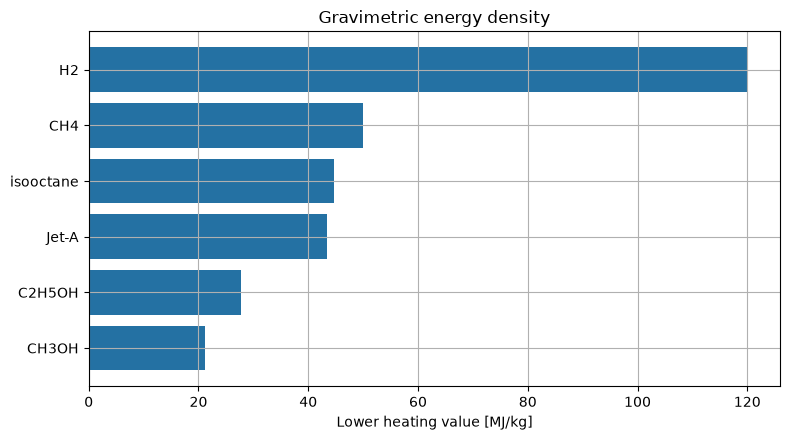

In [5]:
order = fuel_df.sort_values("LHV [MJ/kg]", ascending=True)
fig, ax = plt.subplots()
ax.barh(order.index, order["LHV [MJ/kg]"], color="#2471a3")
ax.set_xlabel("Lower heating value [MJ/kg]")
ax.set_title("Gravimetric energy density")
fig.tight_layout()
plt.show()

## 4. Carbon intensity

Direct combustion CO₂ per unit of delivered energy. Hydrogen emits none at the
point of use; methane is the least carbon-intensive hydrocarbon (high H:C
ratio).

> **Life-cycle caveat.** These are *direct combustion* emissions. Biogenic fuels
> (bioethanol, biomethane, SAF from biomass) recycle atmospheric CO₂, so their
> *net* life-cycle carbon can be far lower than the bar shown here — a central
> theme of GESESC's renewable-energy work.

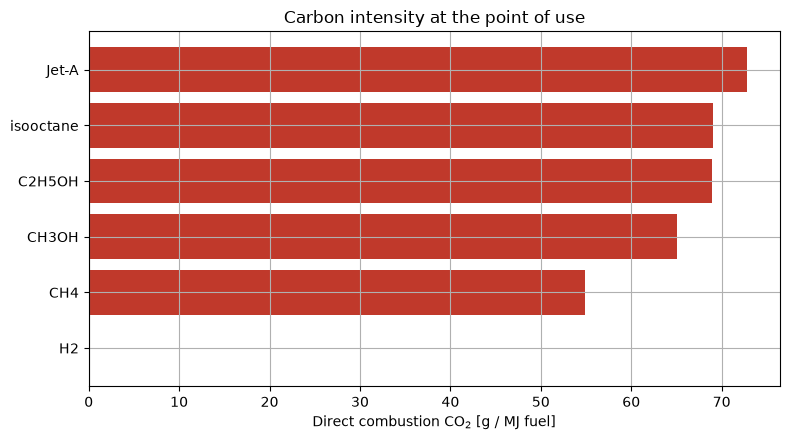

In [6]:
order = fuel_df.sort_values("CO2 [g/MJ]", ascending=True)
colors = ["#27ae60" if v == 0 else "#c0392b" for v in order["CO2 [g/MJ]"]]
fig, ax = plt.subplots()
ax.barh(order.index, order["CO2 [g/MJ]"], color=colors)
ax.set_xlabel("Direct combustion CO$_2$ [g / MJ fuel]")
ax.set_title("Carbon intensity at the point of use")
fig.tight_layout()
plt.show()

## 5. Stoichiometric air-fuel ratio

The AFR sizes the air handling of an engine or combustor. Hydrogen and the pure
hydrocarbons need a lot of air per kilogram of fuel; oxygenated fuels need less
because they carry their own oxygen — relevant to flame speed and NOₓ
formation.

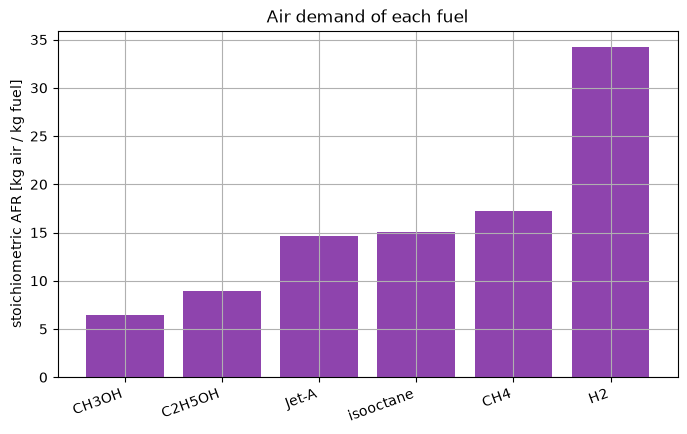

In [7]:
order = fuel_df.sort_values("stoich. AFR [-]", ascending=True)
fig, ax = plt.subplots()
ax.bar(order.index, order["stoich. AFR [-]"], color="#8e44ad")
ax.set_ylabel("stoichiometric AFR [kg air / kg fuel]")
ax.set_title("Air demand of each fuel")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.show()

## 6. Heating value vs. temperature

For ethanol and isooctane we trace how the LHV drifts with temperature
(Kirchhoff's law, notebook 05). The change is small — a few percent — confirming
that room-temperature heating values are usable across combustor-relevant
temperatures.

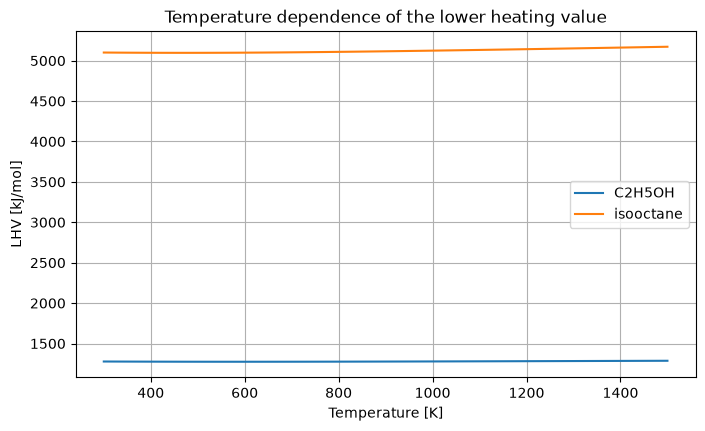

In [8]:
def lhv_at_T(calc, f, T):
    x, y, z = f["x"], f["y"], f["z"]
    nO2 = x + y / 4 - z / 2
    def H(name, nu):
        return nu * calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)["h_relative"]
    dh = (H("CO2", x) + H("H2O", y / 2)) - (H(f["species"], 1) + H("O2", nO2))
    return -dh / 1000.0

Tgrid = np.linspace(300, 1500, 40)
fig, ax = plt.subplots()
with ThermochemicalCalculator() as calc:
    for label in ["C2H5OH", "isooctane"]:
        f = FUELS[label]
        lhv = [lhv_at_T(calc, f, T) for T in Tgrid]
        ax.plot(Tgrid, lhv, label=label)
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("LHV [kJ/mol]")
ax.set_title("Temperature dependence of the lower heating value")
ax.legend()
plt.show()

## Conclusion

- **Bioethanol / methanol**: renewable and clean-burning, but ~35–50 % lower
  energy density than gasoline — acceptable for ground transport, penalising for
  aviation.
- **Isooctane / Jet-A**: high gravimetric and volumetric energy density — hence
  the drive for *drop-in* SAF that matches kerosene's properties while cutting
  life-cycle carbon.
- **Hydrogen**: unmatched energy per kilogram and zero point-of-use CO₂, but its
  storage and air-demand characteristics differ sharply from liquid fuels.

`pyglenn` makes such trade-off screening a few lines of code — exactly the rapid,
programmatic access to thermochemical data the design notes advocate.

**Next:** notebook 08 turns to chemical equilibrium and Gibbs energy.